<a href="https://colab.research.google.com/github/pachterlab/cellmender/blob/main/intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# try:
#     from cellmender import denoise_count_matrix
# except ImportError:
#     print("cellmender not found, installing...")
#     !pip install -U -q cellmender[analysis]

In [2]:
import os
import anndata as ad
import scanpy as sc
from cellmender import denoise_count_matrix
import cellmender.utils as cm_utils

cellmender_dir = os.path.dirname(os.path.abspath(""))

/opt/anaconda3/envs/cellmender/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


# Intro

### Dataset: PBMC 1K from healthy donor (10x Genomics): https://www.10xgenomics.com/datasets/human-pbmc-from-a-healthy-donor-1-k-cells-v-2-2-standard-4-0-0

In [3]:
data_dir = os.path.join(cellmender_dir, "notebooks", "data", "pbmc1k")
os.makedirs(data_dir, exist_ok=True)

out_dir = os.path.join(cellmender_dir, "notebooks", "output", "pbmc1k")
os.makedirs(out_dir, exist_ok=True)

adata_raw_path = os.path.join(data_dir, "sc5p_v2_hs_PBMC_1k_raw_feature_bc_matrix.h5")
if not os.path.exists(adata_raw_path):
    !curl -L -o "{adata_raw_path}" "https://cf.10xgenomics.com/samples/cell-vdj/4.0.0/sc5p_v2_hs_PBMC_1k/sc5p_v2_hs_PBMC_1k_raw_feature_bc_matrix.h5"

adata_raw = sc.read_10x_h5(adata_raw_path)
adata_raw = adata_raw[:, :5000].copy()  # keep only 5000 genes
adata_raw.var_names_make_unique()
expected_cells = 1_200  # slight overestimate since we will do empty droplet removal
model_pkl = "Immune_All_High.pkl"

adata_cellmender_path = os.path.join(out_dir, "adata_cellmender.h5ad")

/opt/anaconda3/envs/cellmender/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/opt/anaconda3/envs/cellmender/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/opt/anaconda3/envs/cellmender/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


## Knee plot - use this output to estimate cs_empty_threshold

UMI cutoff for expected cells (1200): 4.00


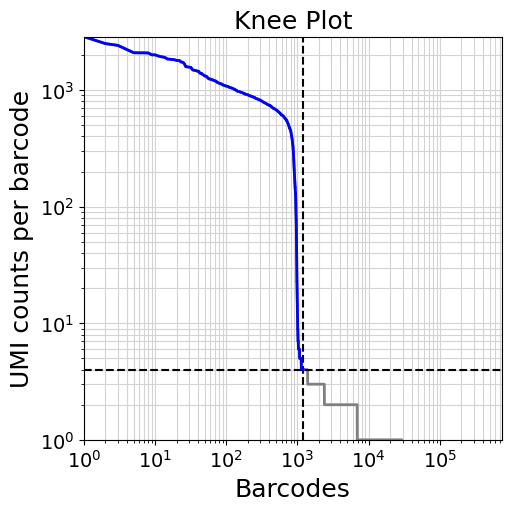

In [4]:
umi_cutoff = cm_utils.knee_plot(adata_raw, expected_cells=expected_cells, out_path=os.path.join(out_dir, "knee_plot.png"))

## Determine cell types - here, we use celltypist, but you can use any method you like

In [5]:
adata = cm_utils.determine_cell_types(adata_raw, model_pkl=model_pkl, filter_empty=True, expected_cells=expected_cells, verbose=2)

15:09:55 - INFO - Filtering empty droplets using column 'is_empty' in adata.obs. If this column is not present, it will be inferred using method 'celltypist' with umi_cutoff=None and expected_cells=1200.
15:09:55 - INFO - 'is_empty' column not found in adata.obs. Inferring empty droplets using method 'celltypist' with umi_cutoff=None and expected_cells=1200.
15:09:55 - INFO - Running cell type annotation using CellTypist with model_pkl=Immune_All_High.pkl. This may take some time depending on the size of the dataset and the model used.
/opt/anaconda3/envs/cellmender/lib/python3.10/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv
📂 Storing models in /Users/mcaskey/.celltypist/data/models
⏩ Skipping [1/58]: Immune_All_Low.pkl (file exists)
⏩ Skipping [2/58]: Immune_All_High.pkl (file exists)
⏩ Skipping [3/58]: Adult_COVID19_PBMC.pkl (file exists)
⏩ Skipping [4/

## Run cellmender

In [ ]:
%time
adata_cellmender = denoise_count_matrix(adata, adata_out=adata_cellmender_path, max_iter=150, beta=0.03, eps=1e-9, empty_droplet_method="threshold", expected_cells=expected_cells, verbose=2, log_file=os.path.join(out_dir, "cellmender.log"))
# adata_cellmender = ad.read_h5ad(adata_cellmender_path)

15:09:59 - INFO - Added 'ambient_fraction' to adata.var.
15:09:59 - INFO - Inferring celltype profiles.


CPU times: user 1 μs, sys: 1 μs, total: 2 μs
Wall time: 1.67 μs
Logging to /Users/mcaskey/Desktop/cellmender/notebooks/output/pbmc1k/cellmender.log


15:10:02 - INFO - EM Iter   1: ll=-3576894.586 beta=0.020811
15:10:02 - INFO - EM Iter   2: ll=-3914565.625 beta=0.020562
15:10:03 - INFO - EM Iter   3: ll=-3904684.038 beta=0.019854
15:10:03 - INFO - EM Iter   4: ll=-3899205.078 beta=0.019027
15:10:04 - INFO - EM Iter   5: ll=-3895532.336 beta=0.018172
15:10:04 - INFO - EM Iter   6: ll=-3892747.116 beta=0.017320
15:10:05 - INFO - EM Iter   7: ll=-3890494.338 beta=0.016484
15:10:05 - INFO - EM Iter   8: ll=-3888647.552 beta=0.015672
15:10:06 - INFO - EM Iter   9: ll=-3887133.812 beta=0.014886
15:10:06 - INFO - EM Iter  10: ll=-3885884.541 beta=0.014130
15:10:07 - INFO - EM Iter  11: ll=-3884850.369 beta=0.013404
15:10:07 - INFO - EM Iter  12: ll=-3883990.897 beta=0.012711
15:10:08 - INFO - EM Iter  13: ll=-3883270.106 beta=0.012049
15:10:08 - INFO - EM Iter  14: ll=-3882661.640 beta=0.011419
15:10:09 - INFO - EM Iter  15: ll=-3882145.210 beta=0.010820
15:10:09 - INFO - EM Iter  16: ll=-3881703.811 beta=0.010250
15:10:10 - INFO - EM Ite

## Filter empty droplets

In [7]:
adata_cellmender = adata_cellmender[~adata_cellmender.obs["is_empty"]].copy()

## Basic analysis

In [8]:
print(f"Raw:\n{adata_raw}\n\n")
print(f"cellmender:\n{adata_cellmender}\n\n")
print("Fraction of cells retained after cellmender:", adata_cellmender.n_obs / adata_raw.n_obs)

Raw:
AnnData object with n_obs × n_vars = 737280 × 5000
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'


cellmender:
AnnData object with n_obs × n_vars = 1385 × 5000
    obs: 'is_empty', 'celltype', 'cell_ambient_fraction', 'alpha_hat', 'z_hat'
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence', 'ambient_fraction', 'ambient_hat'
    uns: 'celltype_profile', 'celltype_names', 'celltype_profile_genes', 'p_hat', 'beta_hat', 'loglike', 'loglik_trace'
    layers: 'denoised'


Fraction of cells retained after cellmender: 0.0018785264756944445


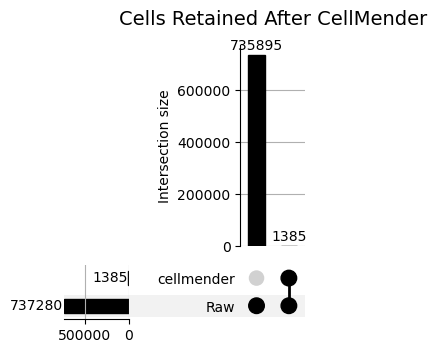

In [9]:
upset_data_dict = {
    "Raw": set(adata_raw.obs_names),
    "cellmender": set(adata_cellmender.obs_names),
}

_ = cm_utils.make_upset_plot(upset_data_dict, title="Cells Retained After CellMender", out_path=os.path.join(out_dir, "cells_retained_upset.png"))

In [10]:
#cm_utils.plot_matrix_scatterplot(adata_raw, adata_cellmender, scale="log", x_axis="raw", y_axis="cellmender", out_path=os.path.join(out_dir, "raw_vs_cellmender_expression_scatterplot.png"), show=True)